In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

income_df = pd.read_csv('/content/income.csv')

display(income_df.head())
print(income_df.info())

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_level
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   fnlwgt          48842 non-null  int64
 2   education_num   48842 non-null  int64
 3   capital_gain    48842 non-null  int64
 4   capital_loss    48842 non-null  int64
 5   hours_per_week  48842 non-null  int64
 6   income_level    48842 non-null  int64
dtypes: int64(7)
memory usage: 2.6 MB
None


### Data Preprocessing for Income Dataset

We need to identify the target variable and features, and then handle categorical features. Based on the previous interaction, the target column is `income_level`.

In [5]:
X_income = income_df.drop('income_level', axis=1)
y_income = income_df['income_level']

le_income = LabelEncoder()
y_income_encoded = le_income.fit_transform(y_income)

categorical_features = X_income.select_dtypes(include=['object']).columns
numerical_features = X_income.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

X_train_income, X_test_income, y_train_income, y_test_income = train_test_split(
    X_income, y_income_encoded, test_size=0.20, random_state=42)

print(f"X_train_income shape: {X_train_income.shape}")
print(f"y_train_income shape: {y_train_income.shape}")
print(f"X_test_income shape: {X_test_income.shape}")
print(f"y_test_income shape: {y_test_income.shape}")

X_train_income shape: (39073, 6)
y_train_income shape: (39073,)
X_test_income shape: (9769, 6)
y_test_income shape: (9769,)


### 1. Build an AdaBoost classifier to classify Income dataset with `n_estimators=10`

We will create a pipeline that first preprocesses the data using `OneHotEncoder` and then applies the AdaBoost classifier.

In [6]:
base_estimator_ada = DecisionTreeClassifier(max_depth=1, random_state=42)

adaboost_default = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(estimator=base_estimator_ada, n_estimators=10, random_state=42))
])

adaboost_default.fit(X_train_income, y_train_income)

y_pred_ada_default = adaboost_default.predict(X_test_income)

accuracy_ada_default = accuracy_score(y_test_income, y_pred_ada_default)
print(f"Accuracy Score with n_estimators=10: {accuracy_ada_default:.4f}")

Accuracy Score with n_estimators=10: 0.8182


### 2. Fine-tune the `n_estimators` for AdaBoost

Now, let's vary the `n_estimators` parameter to find the best possible accuracy.


Best Accuracy Score: 0.8339
Achieved with n_estimators: 81


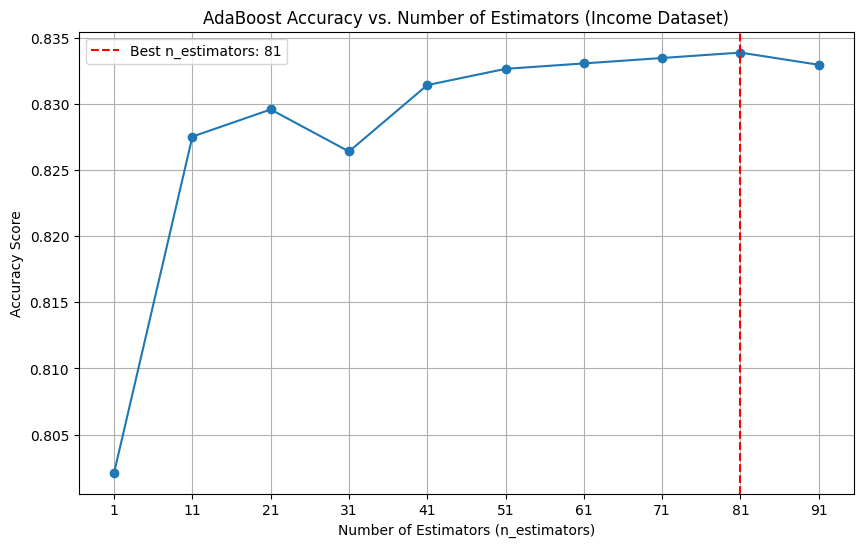

In [7]:
n_estimators_range_ada = range(1, 101, 10)
accuracies_ada = []

for n_est in n_estimators_range_ada:
    adaboost_classifier = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', AdaBoostClassifier(estimator=base_estimator_ada, n_estimators=n_est, random_state=42))
    ])

    adaboost_classifier.fit(X_train_income, y_train_income)

    y_pred_ada = adaboost_classifier.predict(X_test_income)
    accuracies_ada.append(accuracy_score(y_test_income, y_pred_ada))

best_accuracy_ada = max(accuracies_ada)
best_n_estimators_ada = n_estimators_range_ada[accuracies_ada.index(best_accuracy_ada)]

print(f"\nBest Accuracy Score: {best_accuracy_ada:.4f}")
print(f"Achieved with n_estimators: {best_n_estimators_ada}")

plt.figure(figsize=(10, 6))
plt.plot(list(n_estimators_range_ada), accuracies_ada, marker='o', linestyle='-')
plt.title('AdaBoost Accuracy vs. Number of Estimators (Income Dataset)')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.xticks(list(n_estimators_range_ada))
plt.axvline(x=best_n_estimators_ada, color='r', linestyle='--', label=f'Best n_estimators: {best_n_estimators_ada}')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import confusion_matrix

adaboost_classifier_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(estimator=base_estimator_ada, n_estimators=best_n_estimators_ada, random_state=42))
])

adaboost_classifier_best.fit(X_train_income, y_train_income)

y_pred_ada_best = adaboost_classifier_best.predict(X_test_income)

conf_matrix_ada_best = confusion_matrix(y_test_income, y_pred_ada_best)

print(f"\nConfusion Matrix (Best n_estimators={best_n_estimators_ada}):")
print(conf_matrix_ada_best)


Confusion Matrix (Best n_estimators=81):
[[7015  399]
 [1224 1131]]


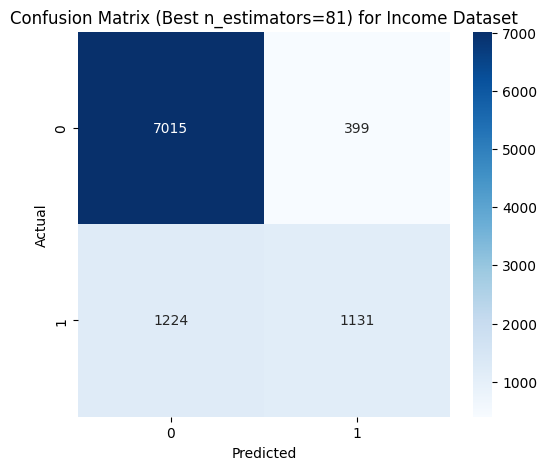

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_ada_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_income.classes_, yticklabels=le_income.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Best n_estimators={best_n_estimators_ada}) for Income Dataset')
plt.show()